## Lets Look At The Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df=pd.read_csv("credit_risk_dataset.csv")


In [2]:
df_clean = df.copy()

df_clean.loc[df_clean["person_age"] > 100, "person_age"] = np.nan
df_clean.loc[df_clean["person_emp_length"] > 50, "person_emp_length"] = np.nan

df_clean = df_clean.drop_duplicates()

df_clean["person_age"] = df_clean["person_age"].fillna(
    df_clean["person_age"].median()
)

df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(
    df_clean["person_emp_length"].median()
)

df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(
    df_clean["loan_int_rate"].median()
)

In [40]:
print("Dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())

Dataset shape: (32416, 12)
Missing values: 0


In [4]:
df.head(20)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
df.shape

(32581, 12)

## This Dataset Has 12 Columns

In [9]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

## Fetches The Columns Which Have Numerical Data

In [10]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(numeric_cols)


['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']


## To Get The Categorial Colums

In [11]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)


['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [12]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [13]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

### Target Distribution: The dataset contains two classes: 0 (non-default) and 1 (default). Approximately 78.183% of observations belong to the non-default class, while 21.816% belong to the default class. Therefore, the target variable exhibits moderate class imbalance.

In [14]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [15]:
(df.isnull().sum() / len(df)) * 100

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [17]:
df.duplicated().sum()

np.int64(165)

In [19]:
df["cb_person_default_on_file"].value_counts()

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

In [20]:
df["person_home_ownership"].value_counts()

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

In [21]:
df["loan_intent"].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [22]:
df["loan_grade"].value_counts()

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

In [23]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [24]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

In [25]:
for column in df.columns:
    print(f"\n--- {column} ---")
    print("Unique values:", df[column].nunique())
    print(df[column].unique()[:20])


--- person_age ---
Unique values: 58
[ 22  21  25  23  24  26 144 123  20  32  34  29  33  28  35  31  27  30
  36  40]

--- person_income ---
Unique values: 4295
[ 59000   9600  65500  54400   9900  77100  78956  83000  10000  85000
  95000 108160 115000 500000 120000  92111 113000  10800 162500 137000]

--- person_home_ownership ---
Unique values: 4
['RENT' 'OWN' 'MORTGAGE' 'OTHER']

--- person_emp_length ---
Unique values: 36
[123.   5.   1.   4.   8.   2.   6.   7.   0.   9.   3.  10.  nan  11.
  18.  12.  17.  14.  16.  13.]

--- loan_intent ---
Unique values: 6
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

--- loan_grade ---
Unique values: 7
['D' 'B' 'C' 'A' 'E' 'F' 'G']

--- loan_amnt ---
Unique values: 753
[35000  1000  5500  2500  1600  4500 30000  1750 34800 34000  1500 33950
 33000  4575  1400 32500  4000  2000 32000 31050]

--- loan_int_rate ---
Unique values: 348
[16.02 11.14 12.87 15.23 14.27  7.14 12.42 11.11  8.9  14.74 10.37  8.6

In [28]:
numerical_cols = df.select_dtypes(include=np.number).columns

print(numerical_cols)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')


In [29]:
categorical_cols = df.select_dtypes(exclude=np.number).columns

print(categorical_cols)

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


In [30]:
for column in numerical_cols:
    print(f"\n--- {column} ---")
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())


--- person_age ---
Minimum: 20
Maximum: 144

--- person_income ---
Minimum: 4000
Maximum: 6000000

--- person_emp_length ---
Minimum: 0.0
Maximum: 123.0

--- loan_amnt ---
Minimum: 500
Maximum: 35000

--- loan_int_rate ---
Minimum: 5.42
Maximum: 23.22

--- loan_status ---
Minimum: 0
Maximum: 1

--- loan_percent_income ---
Minimum: 0.0
Maximum: 0.83

--- cb_person_cred_hist_length ---
Minimum: 2
Maximum: 30


In [31]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
person_age,int64,0,58
person_income,int64,0,4295
person_home_ownership,object,0,4
person_emp_length,float64,895,36
loan_intent,object,0,6
loan_grade,object,0,7
loan_amnt,int64,0,753
loan_int_rate,float64,3116,348
loan_status,int64,0,2
loan_percent_income,float64,0,77


In [34]:
print("Age > 100:")
print(df[df["person_age"] > 100][["person_age", "person_income", "person_emp_length"]])

print("\nEmployment length > 50:")
print(df[df["person_emp_length"] > 50][["person_age", "person_emp_length"]])

print("\nIncome > 1,000,000:")
print(df[df["person_income"] > 1_000_000][["person_age", "person_income"]])

Age > 100:
       person_age  person_income  person_emp_length
81            144         250000                4.0
183           144         200000                4.0
575           123          80004                2.0
747           123          78000                7.0
32297         144        6000000               12.0

Employment length > 50:
     person_age  person_emp_length
0            22              123.0
210          21              123.0

Income > 1,000,000:
       person_age  person_income
17833          32        1200000
29119          36        1200000
29120          40        1200000
30049          42        2039784
31922          47        1362000
31924          44        1440000
32297         144        6000000
32497          63        1782000
32546          60        1900000


## there is a applicant of 144 AGE , this is the reason we run data check before training models

In [35]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- person_home_ownership ---
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

--- loan_intent ---
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

--- loan_grade ---
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

--- cb_person_default_on_file ---
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


In [12]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Rows with invalid age:", (df["person_age"] > 100).sum())
print("Rows with invalid employment length:", (df["person_emp_length"] > 50).sum())

Total rows: 32581
Duplicate rows: 165
Rows with invalid age: 5
Rows with invalid employment length: 2


### now lets fill the weird values with NaN

In [10]:
df_clean = df.copy()

import numpy as np

df_clean.loc[df_clean["person_age"] > 100, "person_age"] = np.nan
df_clean.loc[df_clean["person_emp_length"] > 50, "person_emp_length"] = np.nan

print("Missing age:", df_clean["person_age"].isnull().sum())
print("Missing employment length:", df_clean["person_emp_length"].isnull().sum())

Missing age: 5
Missing employment length: 897


## lets remove duplicates

In [11]:
df_clean = df_clean.drop_duplicates()

print("Rows after removing duplicates:", len(df_clean))

Rows after removing duplicates: 32416


In [39]:
df_clean.isnull().sum()

person_age                       5
person_income                    0
person_home_ownership            0
person_emp_length              889
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [40]:
print("Age median:", df_clean["person_age"].median())
print("Employment length median:", df_clean["person_emp_length"].median())
print("Interest rate median:", df_clean["loan_int_rate"].median())


Age median: 26.0
Employment length median: 4.0
Interest rate median: 10.99


### So we will fill the missing data with medians to preserve data and not distort it

In [13]:
df_clean["person_age"] = df_clean["person_age"].fillna(
    df_clean["person_age"].median()
)

df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(
    df_clean["person_emp_length"].median()
)

df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(
    df_clean["loan_int_rate"].median()
)

In [42]:
df_clean.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## Now we are done with cleaning the Data , The data is now ready For EDA

# Now Lets Begin EDA

In [14]:
df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22.0,59000,RENT,4.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21.0,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25.0,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23.0,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24.0,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [15]:
df_clean["loan_status"].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

In [16]:
df_clean["loan_status"].value_counts(normalize=True) * 100

loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64

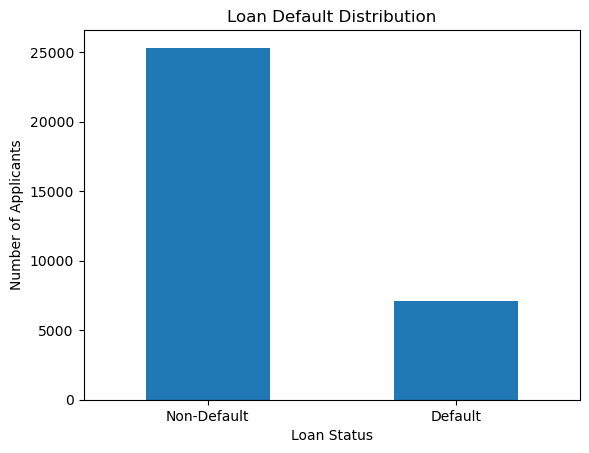

In [18]:
df_clean["loan_status"].value_counts().plot(kind="bar")

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.xticks([0, 1], ["Non-Default", "Default"], rotation=0)
plt.show()

In [19]:
df_clean["person_age"].describe()

count    32416.000000
mean        27.730102
std          6.210006
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max         94.000000
Name: person_age, dtype: float64

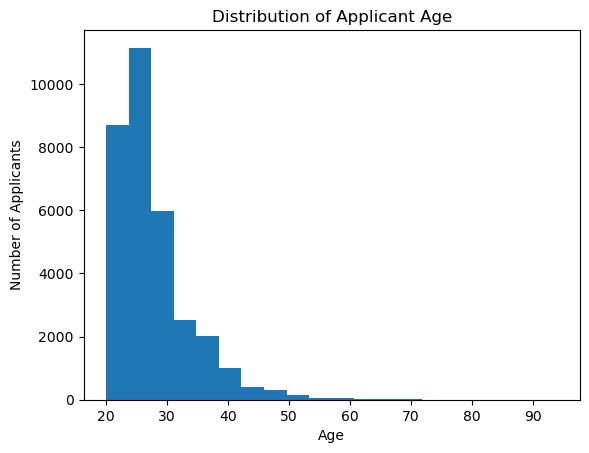

In [20]:
df_clean["person_age"].plot(kind="hist", bins=20)

plt.title("Distribution of Applicant Age")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")
plt.show()

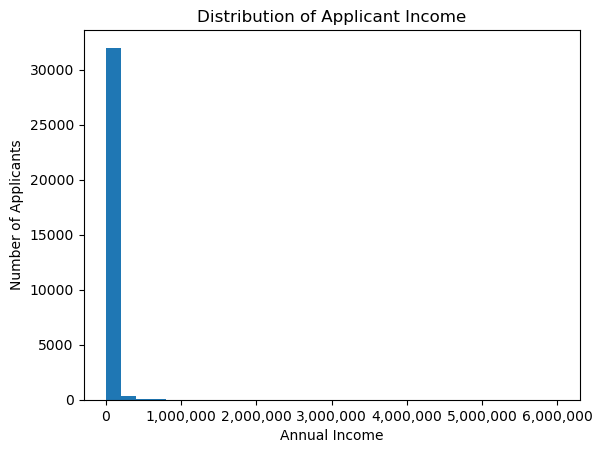

In [22]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

df_clean["person_income"].plot(kind="hist", bins=30)

plt.title("Distribution of Applicant Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.show()

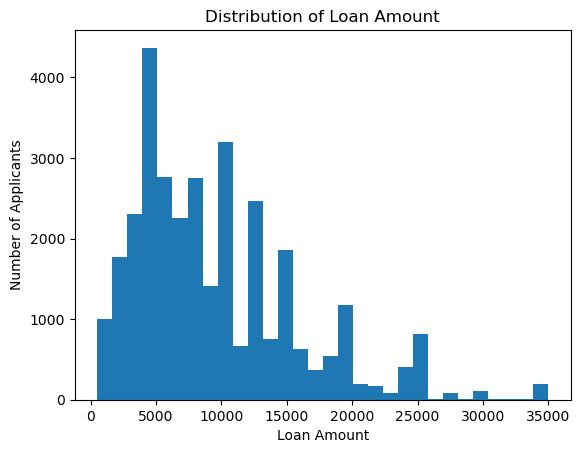

In [23]:
df_clean["loan_amnt"].plot(kind="hist", bins=30)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.show()

### Loan amounts show a moderately right-skewed distribution, with applicants concentrated around lower-to-middle loan amounts and fewer applicants requesting larger loans.

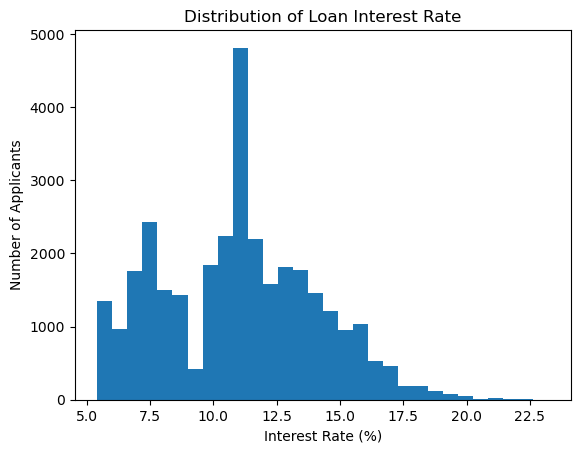

In [24]:
df_clean["loan_int_rate"].plot(kind="hist", bins=30)

plt.title("Distribution of Loan Interest Rate")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Number of Applicants")
plt.show()

### Loan interest rates are concentrated mainly around 10%–12.5%, while relatively fewer applicants have very low or very high interest rates.

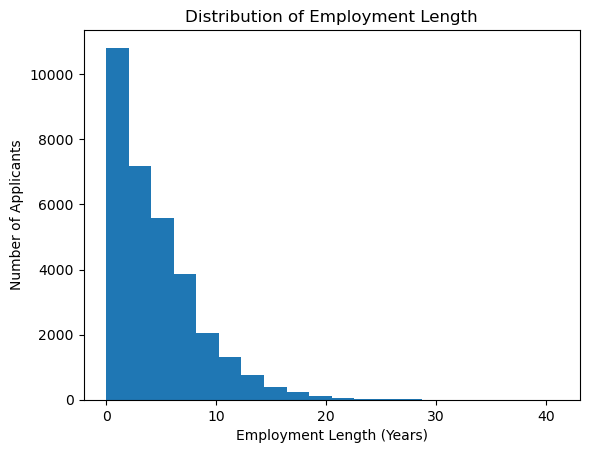

In [25]:
df_clean["person_emp_length"].plot(kind="hist", bins=20)

plt.title("Distribution of Employment Length")
plt.xlabel("Employment Length (Years)")
plt.ylabel("Number of Applicants")
plt.show()

In [26]:
default_by_home = df_clean.groupby("person_home_ownership")["loan_status"].mean() * 100

print(default_by_home)

person_home_ownership
MORTGAGE    12.618745
OTHER       31.132075
OWN          7.491221
RENT        31.609476
Name: loan_status, dtype: float64


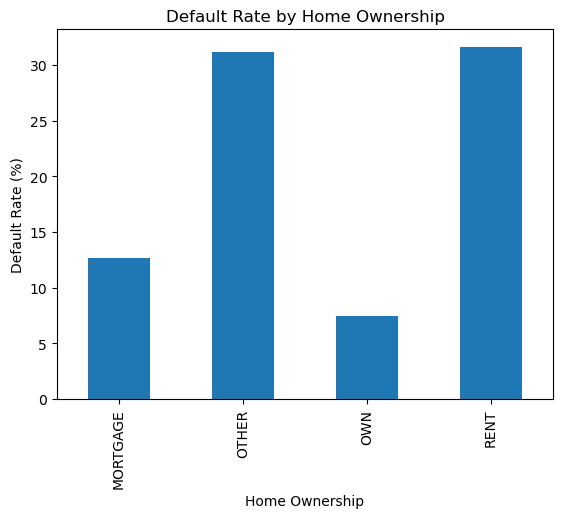

In [27]:
default_by_home.plot(kind="bar")

plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")
plt.show()

### Default rates vary substantially by home-ownership status, with renters showing a considerably higher default rate than applicants who own their homes or have a mortgage.

In [28]:
default_by_intent = df_clean.groupby("loan_intent")["loan_status"].mean() * 100

print(default_by_intent)

loan_intent
DEBTCONSOLIDATION    28.676045
EDUCATION            17.251599
HOMEIMPROVEMENT      26.154702
MEDICAL              26.762661
PERSONAL             19.898145
VENTURE              14.853925
Name: loan_status, dtype: float64


### Default rates vary across loan purposes, with debt-consolidation loans showing the highest observed default rate and venture loans showing the lowest

In [29]:
default_by_grade = df_clean.groupby("loan_grade")["loan_status"].mean() * 100

print(default_by_grade)

loan_grade
A     9.959824
B    16.318475
C    20.751786
D    59.060773
E    64.485981
F    70.539419
G    98.437500
Name: loan_status, dtype: float64


### Default rates increase substantially as loan grade moves from A to G, with Grade G showing an observed default rate of approximately 98.4%.

In [30]:
default_by_history = df_clean.groupby(
    "cb_person_default_on_file"
)["loan_status"].mean() * 100

print(default_by_history)

cb_person_default_on_file
N    18.432886
Y    37.870855
Name: loan_status, dtype: float64


#### “Applicants with a previous recorded default have a substantially higher observed current default rate than applicants without previous defaults.”

In [31]:
df_clean.groupby("loan_status")["person_income"].mean()

loan_status
0    70849.122794
1    49094.497955
Name: person_income, dtype: float64

 #### Applicants who defaulted had a lower average annual income than non-defaulting applicants, suggesting an association between income level and loan default risk.

In [32]:
df_clean.groupby("loan_status")["loan_amnt"].mean()

loan_status
0     9240.155763
1    10857.479898
Name: loan_amnt, dtype: float64

#### Applicants who defaulted had a higher average loan amount than non-defaulting applicants, indicating an association between larger loan amounts and default risk

In [33]:
df_clean.groupby("loan_status")["loan_percent_income"].mean()

loan_status
0    0.148794
1    0.246906
Name: loan_percent_income, dtype: float64

#### Applicants who defaulted had a substantially higher loan-to-income percentage than non-defaulting applicants, suggesting that greater loan burden relative to income is associated with higher default risk


In [34]:
df_clean.groupby("loan_status")["loan_int_rate"].mean()

loan_status
0    10.492585
1    12.879897
Name: loan_int_rate, dtype: float64

#### Applicants who defaulted had higher average loan interest rates than non-defaulting applicants, indicating an association between higher interest rates and default risk.

In [35]:
df_clean.groupby("loan_status")["person_emp_length"].mean()

loan_status
0    4.942749
1    4.114120
Name: person_emp_length, dtype: float64

#### Applicants who defaulted had a slightly shorter average employment length than non-defaulting applicants, suggesting an association between shorter employment history and default risk

In [36]:
df_clean.groupby("loan_status")["person_age"].mean()

loan_status
0    27.801674
1    27.474397
Name: person_age, dtype: float64

#### The average age of defaulting and non-defaulting applicants is very similar, suggesting that age alone shows little difference between the two groups in this dataset

In [37]:
df_clean.groupby("loan_status")["cb_person_cred_hist_length"].mean()

loan_status
0    5.846725
1    5.684723
Name: cb_person_cred_hist_length, dtype: float64

#### Average credit history length is very similar between defaulting and non-defaulting applicants, suggesting that credit history length alone shows little difference between the two groups

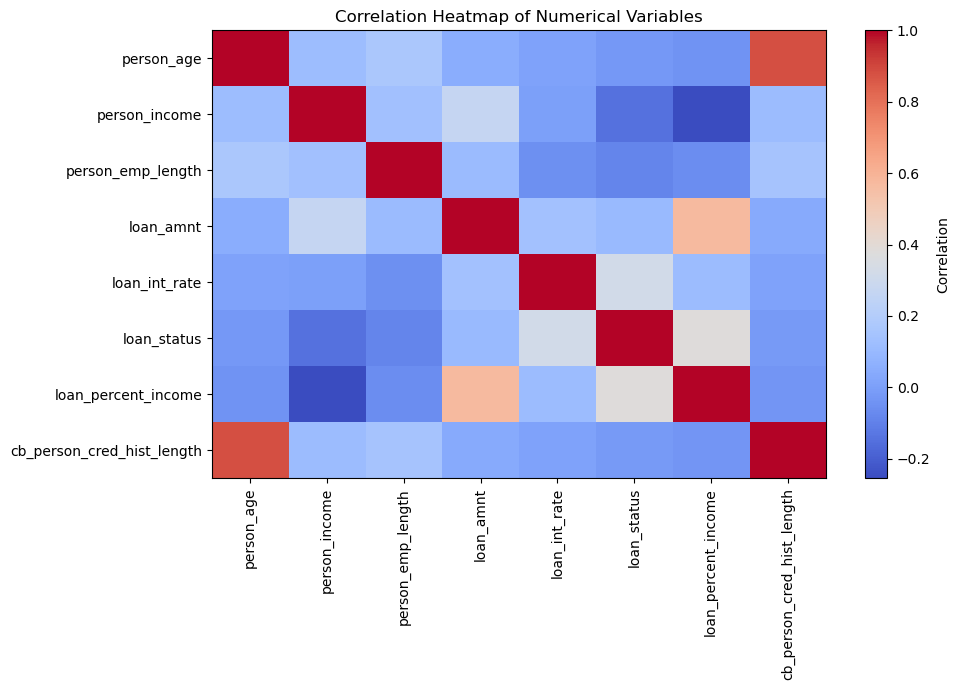

In [38]:
import matplotlib.pyplot as plt

corr = df_clean.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

# Training

In [3]:
X = df_clean.drop("loan_status", axis=1)
y = df_clean["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32416, 11)
y shape: (32416,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (25932, 11)
X_test: (6484, 11)
y_train: (25932,)
y_test: (6484,)


In [6]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [8]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_clean.drop("loan_status", axis=1)
y = df_clean["loan_status"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (25932, 11)
X_test shape: (6484, 11)
y_train shape: (25932,)
y_test shape: (6484,)


In [9]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

Preprocessing completed successfully.
X_train_processed shape: (25932, 26)
X_test_processed shape: (6484, 26)


### Logistic reg model

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_processed, y_train)

print("Model trained successfully.")

Model trained successfully.


In [11]:
y_pred = model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 6484


In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8693707587908698

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5066
           1       0.77      0.57      0.66      1418

    accuracy                           0.87      6484
   macro avg       0.83      0.76      0.79      6484
weighted avg       0.86      0.87      0.86      6484


Confusion Matrix:
[[4830  236]
 [ 611  807]]


### Random forest model

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [14]:
rf_y_pred = rf_model.predict(X_test_processed)

print("Random Forest predictions generated successfully.")
print("Number of predictions:", len(rf_y_pred))

Random Forest predictions generated successfully.
Number of predictions: 6484


In [15]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_y_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_y_pred))

Random Forest Accuracy: 0.9346082665021591

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.97      0.72      0.83      1418

    accuracy                           0.93      6484
   macro avg       0.95      0.86      0.89      6484
weighted avg       0.94      0.93      0.93      6484


Random Forest Confusion Matrix:
[[5036   30]
 [ 394 1024]]


### Random forest is comparitively good

In [16]:
rf_y_prob = rf_model.predict_proba(X_test_processed)[:, 1]

print("Probability predictions generated successfully.")
print("Number of probabilities:", len(rf_y_prob))

Probability predictions generated successfully.
Number of probabilities: 6484


In [17]:
rf_y_prob = rf_model.predict_proba(X_test_processed)[:, 1]

print("Probability predictions generated successfully.")
print("Number of probabilities:", len(rf_y_prob))

Probability predictions generated successfully.
Number of probabilities: 6484


In [18]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, rf_y_prob)

print("Random Forest PR-AUC:", pr_auc)

Random Forest PR-AUC: 0.8824458574448899


In [19]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 26
['num__person_age' 'num__person_income' 'num__person_emp_length'
 'num__loan_amnt' 'num__loan_int_rate' 'num__loan_percent_income'
 'num__cb_person_cred_hist_length' 'cat__person_home_ownership_MORTGAGE'
 'cat__person_home_ownership_OTHER' 'cat__person_home_ownership_OWN'
 'cat__person_home_ownership_RENT' 'cat__loan_intent_DEBTCONSOLIDATION'
 'cat__loan_intent_EDUCATION' 'cat__loan_intent_HOMEIMPROVEMENT'
 'cat__loan_intent_MEDICAL' 'cat__loan_intent_PERSONAL'
 'cat__loan_intent_VENTURE' 'cat__loan_grade_A' 'cat__loan_grade_B'
 'cat__loan_grade_C' 'cat__loan_grade_D' 'cat__loan_grade_E'
 'cat__loan_grade_F' 'cat__loan_grade_G'
 'cat__cb_person_default_on_file_N' 'cat__cb_person_default_on_file_Y']


In [20]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                                Feature  Importance
5              num__loan_percent_income    0.222464
1                    num__person_income    0.139725
4                    num__loan_int_rate    0.108109
3                        num__loan_amnt    0.074137
2                num__person_emp_length    0.060408
10      cat__person_home_ownership_RENT    0.059994
20                    cat__loan_grade_D    0.054034
0                       num__person_age    0.045040
6       num__cb_person_cred_hist_length    0.034470
7   cat__person_home_ownership_MORTGAGE    0.026836
11   cat__loan_intent_DEBTCONSOLIDATION    0.023707
14             cat__loan_intent_MEDICAL    0.020922
19                    cat__loan_grade_C    0.019982
9        cat__person_home_ownership_OWN    0.018562
13     cat__loan_intent_HOMEIMPROVEMENT    0.013011
21                    cat__loan_grade_E    0.012859
17                    cat__loan_grade_A    0.011194
12           cat__loan_intent_EDUCATION    0.010665
16          

## Now Lets Predict Some Datas

In [21]:
new_applicant = pd.DataFrame({
    "person_age": [25],
    "person_income": [50000],
    "person_home_ownership": ["RENT"],
    "person_emp_length": [3],
    "loan_intent": ["EDUCATION"],
    "loan_grade": ["B"],
    "loan_amnt": [8000],
    "loan_int_rate": [10.5],
    "loan_percent_income": [0.16],
    "cb_person_default_on_file": ["N"],
    "cb_person_cred_hist_length": [4]
})

new_applicant_processed = preprocessor.transform(new_applicant)

prediction = rf_model.predict(new_applicant_processed)
probability = rf_model.predict_proba(new_applicant_processed)[0][1]

if prediction[0] == 1:
    print("Prediction: Loan Default")
else:
    print("Prediction: No Loan Default")

print(f"Default Probability: {probability:.2%}")

Prediction: No Loan Default
Default Probability: 7.50%


In [22]:
%load_ext autoreload
%autoreload 2
